# Event Contract Pricer

**What this is:** An event contract pays a fixed amount if a condition holds at expiry
and nothing otherwise, which makes it a digital (binary) option. Its price is the
discounted risk neutral probability of the event.

**Why it matters:** This notebook prices the same contract three ways, under a flat
volatility assumption, under Heston, and by call spread replication. The third of these
is how a digital is actually hedged, due to its payoff being discontinuous at the strike
and its delta being unbounded there, which means no finite position in the underlying
hedges it.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
import sys, pathlib

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm
from scipy.interpolate import CubicSpline
from src.models import simulate_heston
plt.style.use("seaborn-v0_8")

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | asset spot price at time zero |
| $K$ | `K` | strike price of the contract |
| $r$ | `r` | risk free rate |
| $\sigma$ | `sigma` | flat volatility used by the closed form pricer |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $M$ | `num_paths` | number of Monte Carlo paths |

In [2]:
SEED = 20260913

S0 = 100
K = 90
r = 0.03
sigma = 0.2
T = 1
n = 252
dt = T/n
num_paths = 50_000


## Flat volatility digital pricer

**Flat volatility price:**

$$FV(K) = e^{-rT}\mathbf{N}(d_2)$$

where $d_2$ is given by,

$$d_2 = \frac{\ln(\frac{S_0​}{K})+(r- \frac{1}{2} \sigma^2)T}{\sigma\sqrt{T}}$$



In [3]:
# Flat Vol Digital Pricer
FV_Pricer = lambda K: np.exp(-r * (T)) * norm.cdf((np.log(S0 / K) + (r - 0.5 * sigma ** 2) * (T)) / (sigma * np.sqrt(T)))

In [4]:
FV_Price = FV_Pricer(K)
print(f"Flat Vol. Digital Price: ${FV_Price:.4f}")

Flat Vol. Digital Price: $0.6967


## Heston parameters

| Symbol | Code | Meaning |
|---|---|---|
| $v_0$ | `sigma**2` | initial variance, set to the flat volatility squared |
| $\kappa$ | `kappa` | mean reversion rate of the variance |
| $\theta$ | `theta` | long run mean variance |
| $\xi$ | `xi` | volatility of volatility |
| $\rho$ | `rho` | correlation between the price and variance shocks |
| $\mu$ | `mu` | drift of the price process |
| $\varepsilon^{S}_{i,j},\ \varepsilon^{v}_{i,j}$ | `epsilon_S`, `epsilon_v` | correlated standard normal shocks, generated inside `src/models.py` |

Setting $v_0 = \sigma^2$ starts the Heston paths at the same instantaneous volatility the
flat volatility pricer assumes throughout, so the two prices differ only because of the
variance dynamics rather than because of a different starting point.

In [5]:
rho = -0.7
T = 1
dt = T / n
theta = 0.05
kappa = 6
xi = 0.4
mu = 0.03
S0 = 100

## Heston model simulation

**Heston Model Given By:**

$$S_{t+1} = S_t + \mu S_t \Delta t + S_t\sqrt{\text{max}(v_t,0)}\sqrt{\Delta t} \epsilon^S_t$$

With stochastic volatility process,

$$v_{t+1} = v_t + \kappa(\theta - \text{max}(v_t,0))\Delta t + \xi\sqrt{\text{max}(v_t,0)} \sqrt{\Delta t} \epsilon^v_t$$

Where $\epsilon^v$ is given by

$$ \epsilon^v = \rho\epsilon^S+\sqrt{1-\rho^2}Z$$

($Z$ is a random normal variable, but is not the same as the one used for GBM)

In [6]:
S_H, v = simulate_heston(S0=S0, v0=sigma**2, n=n, dt=dt, kappa=kappa, theta=theta, xi=xi, rho=rho, mu=mu, num_paths=num_paths, rng=SEED)

## Monte Carlo vanilla call pricing

**Ground Truth Digital Price Given By:**

$$GT_{DP} = e^{-r T}\cdot\text{mean}(S_{T} > K)$$

**Monte Carlo Vanilla Call Price Given By:**

$$C_{MC} = e^{-rT}\cdot\text{mean}(\text{max}(S_{T}-K,0))$$

In [7]:
GT_DP = lambda K: np.mean(S_H[-1] > K)* np.exp(-r * T) #Ground Truth Digital Price
K_arr = np.linspace(70, 130, 31)
C_MC = [np.exp(-r * T) * np.mean(np.maximum(S_H[-1]-k,0)) for k in K_arr] #Monte Carlo Vanilla Call Price

## Heston vs. flat volatility

In [8]:
print(f"Heston Price: ${GT_DP(90):.4f}")
print(f"Flat Vol. Price: ${FV_Price:.4f}")
print(f"Diff (Heston - Flat): ${GT_DP(90)-FV_Price:.4f}")

Heston Price: $0.6953
Flat Vol. Price: $0.6967
Diff (Heston - Flat): $-0.0015


## Black-Scholes pricing

**Black Scholes Price Given By:**

$$C_{BS} = S_0 \mathbf{N}(d_1) - K e ^{-rT}\mathbf{N}(d_2)$$

where $d_1$ and $d_2$ are,

$$d_1 = \frac{\ln(\frac{S_0}{K}) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

In [9]:
def C_BS(K:float,sigma:float)->float:
  d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)

  return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

## Implied volatility

$\hat{\sigma}(K)$ (implied volatility) is given by solving the equation below. In this example Brent's method is used to solve for $\hat{\sigma}(K)$.

$$C_{BS}(K,\hat{\sigma}(K)) = C_{MC}(K)$$

Due to the implied volatility only being computed for 31 strikes, a cubic-spline is fit to interpolate the rest of the strikes in the range.

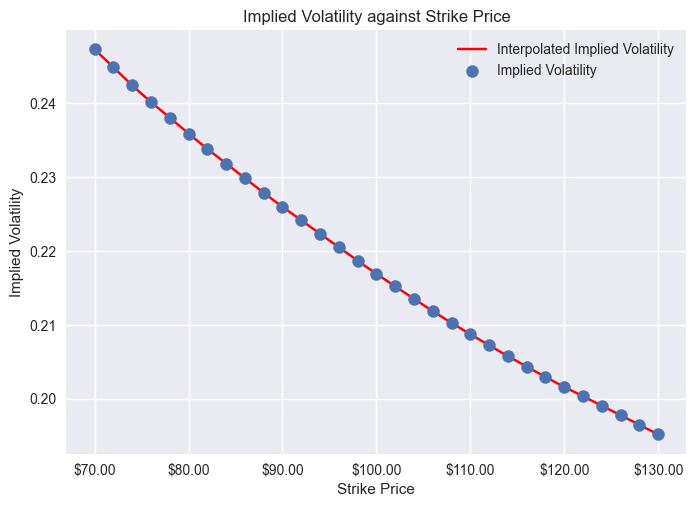

In [10]:
Impl_Vol = [brentq(lambda s: C_BS(K_arr[i], s) - C_MC[i], 1e-4, 1) for i in range(31)]

Interpolated_Func = CubicSpline(K_arr, Impl_Vol)

plt.title("Implied Volatility against Strike Price")
plt.plot(np.linspace(70,130,1000),[Interpolated_Func(i) for i in np.linspace(70,130,1000)],c="r",label="Interpolated Implied Volatility")
plt.scatter(K_arr,Impl_Vol,s=75,zorder=2,label="Implied Volatility")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.gca().xaxis.set_major_formatter("${x:,.2f}")
plt.legend()
plt.show()

**Implied Volatility against Strike Price Plot:**

Implied volatility slopes downward from ~26% when K=\$70 to less than 20% when K=\$130. Given that $\rho$ = -0.7, it is implied that variance rises with downward moves. Ultimately this means that lower strikes carry more implied volatility.  

## Call spread replication

**$\text{Digital}(K)=-\frac{\partial C}{\partial K}$ is approximated by:**

$$\text{Digital}(K,\varepsilon)\approx-\frac{C_{BS}(K+\varepsilon,\hat{\sigma}(K+\varepsilon))-C_{BS}(K-\varepsilon,\hat{\sigma}(K-\varepsilon))}{2\varepsilon}$$

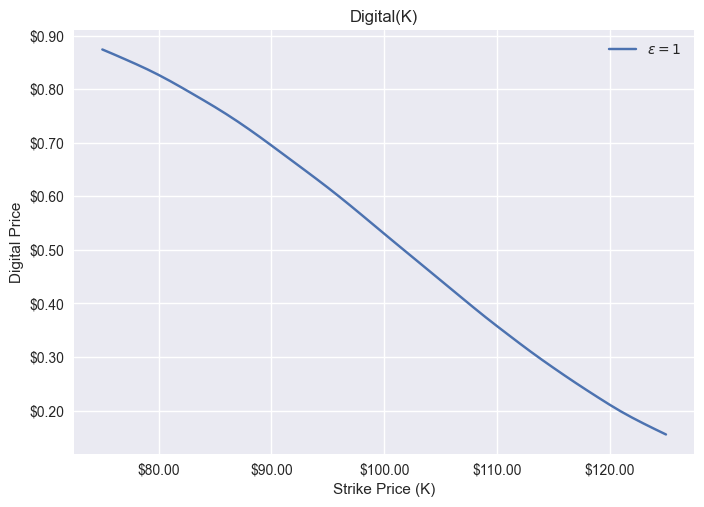

In [11]:
sigma_p = lambda k, e: Interpolated_Func(k+e)
sigma_m = lambda k, e: Interpolated_Func(k-e)
Strikes = np.arange(75,125+1)
e = 1
Digital = lambda k,e: -(C_BS(k+e,sigma_p(k,e)) - C_BS(k-e,sigma_m(k,e))) / (2*e)

plt.title("Digital(K)")
plt.plot(Strikes,Digital(Strikes,e),label=r"$\varepsilon=1$")
plt.xlabel("Strike Price (K)")
plt.ylabel("Digital Price")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("${x:,.2f}")
plt.legend()
plt.show()

## Comparing prices

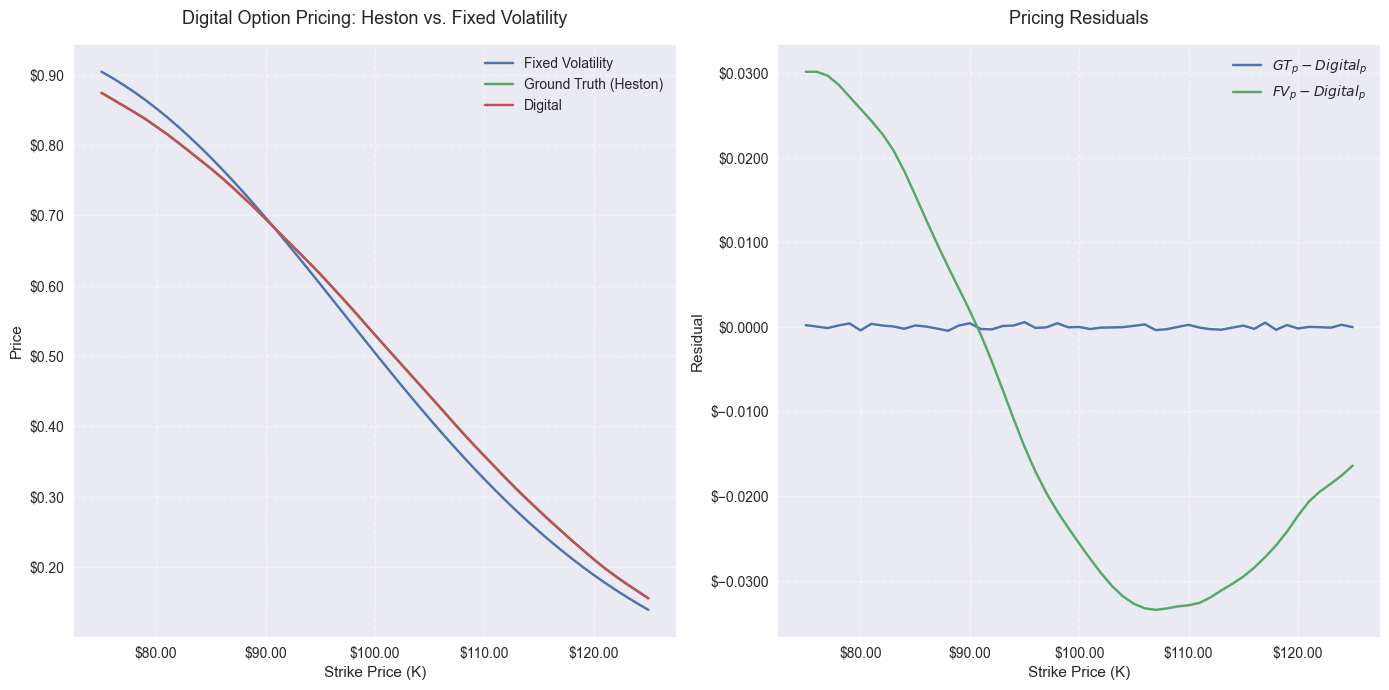

In [12]:
gt_prices = np.array([GT_DP(s) for s in Strikes])
digital_prices = Digital(Strikes,e)
fv_prices = FV_Pricer(Strikes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.set_title("Digital Option Pricing: Heston vs. Fixed Volatility", fontsize=13, pad=15)
ax1.plot(Strikes, fv_prices, label="Fixed Volatility")
ax1.plot(Strikes, gt_prices, label="Ground Truth (Heston)")
ax1.plot(Strikes, digital_prices, label="Digital")
ax1.yaxis.set_major_formatter("${x:,.2f}")
ax1.xaxis.set_major_formatter("${x:,.2f}")
ax1.set_xlabel("Strike Price (K)")
ax1.set_ylabel("Price")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.set_title("Pricing Residuals", fontsize=13, pad=15)
ax2.plot(Strikes, gt_prices - digital_prices, label=r"$GT_p - Digital_p$")
ax2.plot(Strikes, fv_prices - digital_prices, label=r"$FV_p - Digital_p$")
ax2.yaxis.set_major_formatter("${x:,.4f}")
ax2.xaxis.set_major_formatter("${x:,.2f}")
ax2.set_xlabel("Strike Price (K)")
ax2.set_ylabel("Residual")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Digital Option Pricing (Heston vs. Fixed Volatility) Plot:**

Skew-aware digital pricing closely tracks the Heston ground truth across the full range of strikes. It does this while the flat volatility price deviates from the skew-aware price either being higher or lower depending on what side of the spot price the strike sits on.

**Pricing Residuals Plot:**

$GT_{p} - \text{Digital}_p$ stays under \$0.001 for every strike in the range. $FV_{p} - \text{Digital}_p$ is around \$0.03 - \$0.04 near its maximum. The skew-aware approximation is over 30x closer to the ground truth price than the flat volatility baseline is.

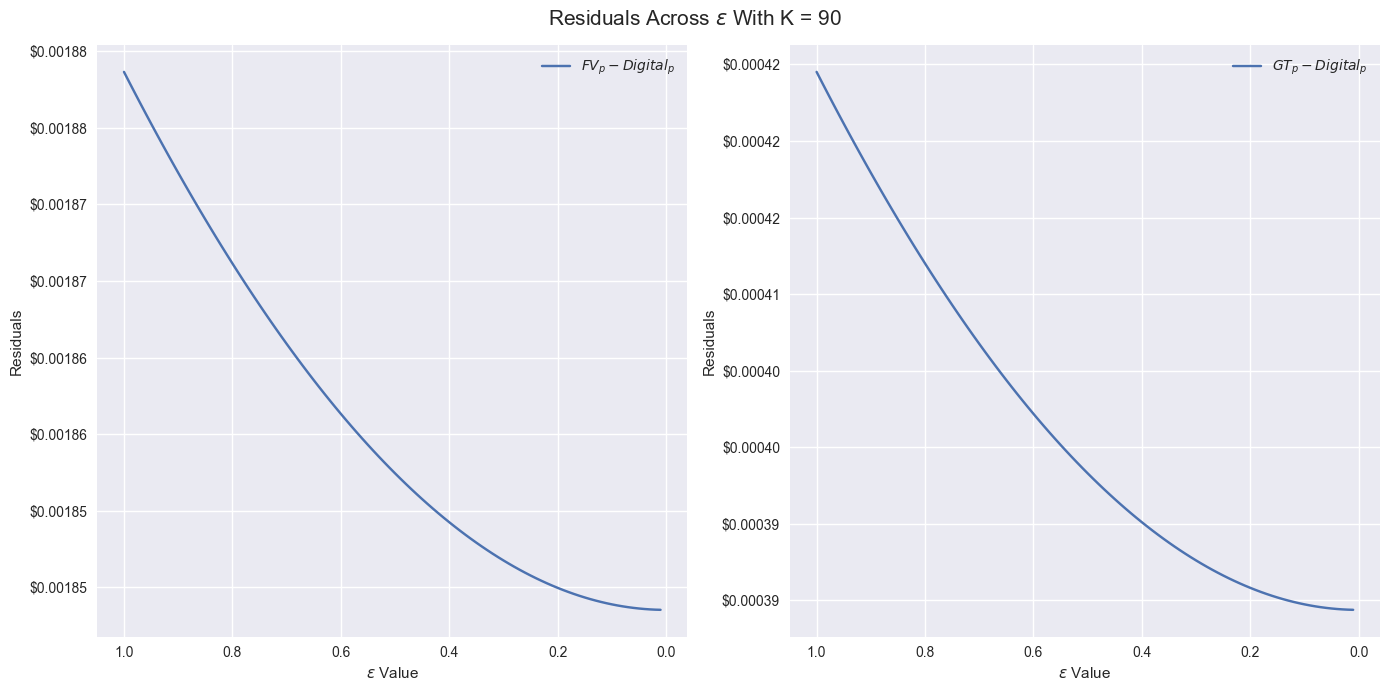

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(r"Residuals Across $\varepsilon$ With K = 90",fontsize=15)
Digital_E = np.linspace(0.01,1,100)

ax1.plot(Digital_E,FV_Pricer(K)-Digital(K,Digital_E),label=r"$FV_p - Digital_p$")
ax1.invert_xaxis()
ax1.set_xlabel(r"$\varepsilon$ Value")
ax1.set_ylabel("Residuals")
ax1.yaxis.set_major_formatter("${x:,.5f}")
ax1.legend()

ax2.plot(Digital_E,GT_DP(K)-Digital(K,Digital_E),label=r"$GT_p - Digital_p$")
ax2.invert_xaxis()
ax2.set_xlabel(r"$\varepsilon$ Value")
ax2.set_ylabel("Residuals")
ax2.yaxis.set_major_formatter("${x:,.5f}")
ax2.legend()

plt.tight_layout()
plt.show()

As $\varepsilon \rightarrow 0$ both residual plots converge with no instability. This confirms that $\varepsilon=1$ is inside of the safe range for finite-difference approximation.